# Per-neuron static–dynamic response regressions

This notebook extends `static_dynamic_tuning_curves.ipynb` from the population response to every retained neuron separately. For each neuron, it averages activity inside independently adjustable static and dynamic time windows and fits

$$\mathrm{static\ activity} = \beta_0 + \beta_1 \, \mathrm{dynamic\ activity}.$$

Each point in a neuron panel is one matched stimulus. The panel shows the identity line, fitted regression line, Spearman rank correlation, slope, intercept, and $R^2$. A second figure summarizes the distributions of slopes and intercepts across neurons.

In [1]:
import os
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml
from sklearn.linear_model import LinearRegression


# Locate the repository whether the notebook starts in the project root or scripts/.
working_directory = Path.cwd().resolve()
project_candidates = (working_directory, *working_directory.parents)
PROJECT_ROOT = next(
    candidate for candidate in project_candidates
    if (candidate / "config.yaml").is_file()
)
ENV = os.getenv("MY_ENV", "tiziano_mac_mini")

with open(PROJECT_ROOT / "config.yaml", "r") as file:
    config = yaml.safe_load(file)
# end with open

paths = config[ENV]["paths"]
for source_path in (paths["src_path"], paths["useful_stuff_path"]):
    if source_path not in sys.path:
        sys.path.append(source_path)
    # end if source_path
# end for source_path

from project_specific_utils import (
    bootstrap_rowwise_orthogonal_slopes,
    load_natraster,
    match_timed_static_movie_rasters,
    rowwise_orthogonal_regression,
    rowwise_similarity,
    window_mean_responses,
)

## Configuration

Edit `static_window_ms` and `dynamic_window_ms` to change the averaging periods. Windows are half-open: the start is included and the end is excluded. Set `dynamic_window_ms=None` to shift the static window automatically to the movie time associated with `static_response`. `good_channels` uses inclusive, one-based MATLAB channel numbers; use `None` for every channel.

In [2]:
@dataclass
class Cfg:
    static_exp_name: str = "red_20260726to27" # "baby1_260718to27"
    dynamic_exp_name: str = "red_20260720to24" #"baby1_260716to24"

    # Options: "last_frame", "2000ms", or "2250ms".
    static_response: str = "last_frame"
    good_channels: tuple[int, int] | None = None #(84, 186)
    use_reliable_channels: bool = True
    reliable_channels_config: Path | None = None
    reliable_channels_key: str | None = None

    source_fs: float = 1000
    static_window_ms: tuple[float, float] = (100, 500)
    # None aligns this window to the selected frame; a tuple overrides it.
    dynamic_window_ms: tuple[float, float] | None = (2500, 2900)

    neuron_plot_columns: int = 5
    distribution_bin_count: int = 15
    bootstrap_repeats: int = 1000
    bootstrap_confidence_level: float = 0.95
    random_seed: int = 0
    figure_dpi: int = 120
# EOC


cfg = Cfg()
frame_time_ms_by_static_response = {
    "last_frame": 2500,
    "2000ms": 2000,
    "2250ms": 2250,
}
if cfg.static_response not in frame_time_ms_by_static_response:
    raise ValueError(
        "static_response must be 'last_frame', '2000ms', or '2250ms'."
    )
# end if invalid static_response
if cfg.neuron_plot_columns < 1:
    raise ValueError("neuron_plot_columns must be positive.")
# end if invalid column count

selected_frame_time_ms = frame_time_ms_by_static_response[
    cfg.static_response
]
if cfg.dynamic_window_ms is None:
    analysis_dynamic_window_ms = tuple(
        selected_frame_time_ms + time_ms
        for time_ms in cfg.static_window_ms
    )
else:
    analysis_dynamic_window_ms = cfg.dynamic_window_ms
# end if cfg.dynamic_window_ms is None

plt.rcParams["figure.dpi"] = cfg.figure_dpi
cfg

Cfg(static_exp_name='red_20260726to27', dynamic_exp_name='red_20260720to24', static_response='last_frame', good_channels=None, use_reliable_channels=True, reliable_channels_config=None, reliable_channels_key=None, source_fs=1000, static_window_ms=(100, 500), dynamic_window_ms=(2500, 2900), neuron_plot_columns=5, distribution_bin_count=15, bootstrap_repeats=1000, bootstrap_confidence_level=0.95, random_seed=0, figure_dpi=120)

## Load and align matched static and dynamic stimuli

The loading and alignment are intentionally identical to `static_dynamic_tuning_curves.ipynb`. The same physical channels are retained in both sessions, and stimulus identities are matched after removing their condition prefixes.

In [3]:
data_dir = Path(paths["data_path"]) / "data"
static_path = data_dir / f"{cfg.static_exp_name}_natraster_img.mat"
dynamic_path = data_dir / f"{cfg.dynamic_exp_name}_natraster_vid.mat"

# By default, use the reliability list estimated from the static session.
reliable_channels_config = None
reliable_channels_key = None
if cfg.use_reliable_channels:
    reliable_channels_config = (
        cfg.reliable_channels_config
        or PROJECT_ROOT / "reliable_channels.yaml"
    )
    reliable_channels_key = (
        cfg.reliable_channels_key or cfg.static_exp_name
    )
# end if cfg.use_reliable_channels

# Apply the same physical-channel selection to both recording sessions.
loaded_static, static_names, static_channel_numbers = load_natraster(
    static_path,
    good_channels=cfg.good_channels,
    reliable_channels_config=reliable_channels_config,
    reliable_channels_key=reliable_channels_key,
    return_channel_numbers=True,
)
loaded_dynamic, dynamic_names, dynamic_channel_numbers = load_natraster(
    dynamic_path,
    good_channels=cfg.good_channels,
    reliable_channels_config=reliable_channels_config,
    reliable_channels_key=reliable_channels_key,
    return_channel_numbers=True,
)
if not np.array_equal(static_channel_numbers, dynamic_channel_numbers):
    raise ValueError(
        "Static and dynamic sessions retained different physical channels."
    )
# end if retained channels differ
channel_numbers = static_channel_numbers

(
    last_frame_rasters,
    dynamic_rasters,
    image_2000ms_rasters,
    image_2250ms_rasters,
    shared_stimuli,
    aligned_names,
) = match_timed_static_movie_rasters(
    loaded_static, static_names, loaded_dynamic, dynamic_names,
)

static_rasters_by_response = {
    "last_frame": last_frame_rasters,
    "2000ms": image_2000ms_rasters,
    "2250ms": image_2250ms_rasters,
}
static_rasters = static_rasters_by_response[cfg.static_response]

print(f"Static natraster:  {static_path}")
print(f"Dynamic natraster: {dynamic_path}")
print(f"Matched stimuli: {len(shared_stimuli)}")
print(f"Selected neuron count: {len(channel_numbers)}")
print(f"Selected MATLAB channels: {channel_numbers.tolist()}")
print("Static shape: ", static_rasters.shape, "(neurons, time, stimuli)")
print("Dynamic shape:", dynamic_rasters.shape, "(neurons, time, stimuli)")

Static natraster:  /Users/tizianocausin/sd_local/data/red_20260726to27_natraster_img.mat
Dynamic natraster: /Users/tizianocausin/sd_local/data/red_20260720to24_natraster_vid.mat
Matched stimuli: 100
Selected neuron count: 12
Selected MATLAB channels: [3, 7, 10, 17, 20, 22, 29, 43, 44, 45, 46, 55]
Static shape:  (12, 1000, 100) (neurons, time, stimuli)
Dynamic shape: (12, 3500, 100) (neurons, time, stimuli)


## Time-average each neuron and fit the regressions

For every neuron, the matched stimuli are the observations. `LinearRegression` fits static responses from dynamic responses with an intercept. A neuron with constant dynamic activity has no identifiable slope and is retained in the scatterplot but marked as an undefined regression.

In [4]:
static_channel_responses, static_sample_window = window_mean_responses(
    static_rasters, cfg.static_window_ms, cfg.source_fs,
)
dynamic_channel_responses, dynamic_sample_window = window_mean_responses(
    dynamic_rasters, analysis_dynamic_window_ms, cfg.source_fs,
)

neuron_count = static_channel_responses.shape[0]
intercepts = np.full(neuron_count, np.nan)
slopes = np.full(neuron_count, np.nan)
r_squared = np.full(neuron_count, np.nan)
dynamic_response_ranges = np.ptp(dynamic_channel_responses, axis=1)
valid_regressions = dynamic_response_ranges > 0

# Fit one independent regression across matched stimuli for every neuron.
for neuron_index in np.flatnonzero(valid_regressions):
    dynamic_activity = dynamic_channel_responses[neuron_index, :, np.newaxis]
    static_activity = static_channel_responses[neuron_index]

    regression = LinearRegression()
    regression.fit(dynamic_activity, static_activity)

    intercepts[neuron_index] = regression.intercept_
    slopes[neuron_index] = regression.coef_[0]
    r_squared[neuron_index] = regression.score(
        dynamic_activity, static_activity,
    )
# end for neuron_index

channel_rank_correlations = rowwise_similarity(
    static_channel_responses,
    dynamic_channel_responses,
    metric="spearman",
)
channel_linear_correlations = rowwise_similarity(
    static_channel_responses,
    dynamic_channel_responses,
    metric="correlation",
)

print(
    f"Static window:  {cfg.static_window_ms} ms -> samples "
    f"{static_sample_window[0]}:{static_sample_window[1]}"
)
print(
    f"Dynamic window: {analysis_dynamic_window_ms} ms -> samples "
    f"{dynamic_sample_window[0]}:{dynamic_sample_window[1]}"
)
print(f"Valid regressions: {valid_regressions.sum()} / {neuron_count}")

Static window:  (100, 500) ms -> samples 100:500
Dynamic window: (2500, 2900) ms -> samples 2500:2900
Valid regressions: 12 / 12


## Per-neuron static–dynamic scatterplots

Each panel uses equal x/y scales so the dashed identity line is meaningful. The orange line is the fitted equation. Different neurons retain their own activity limits because their response magnitudes can differ substantially.

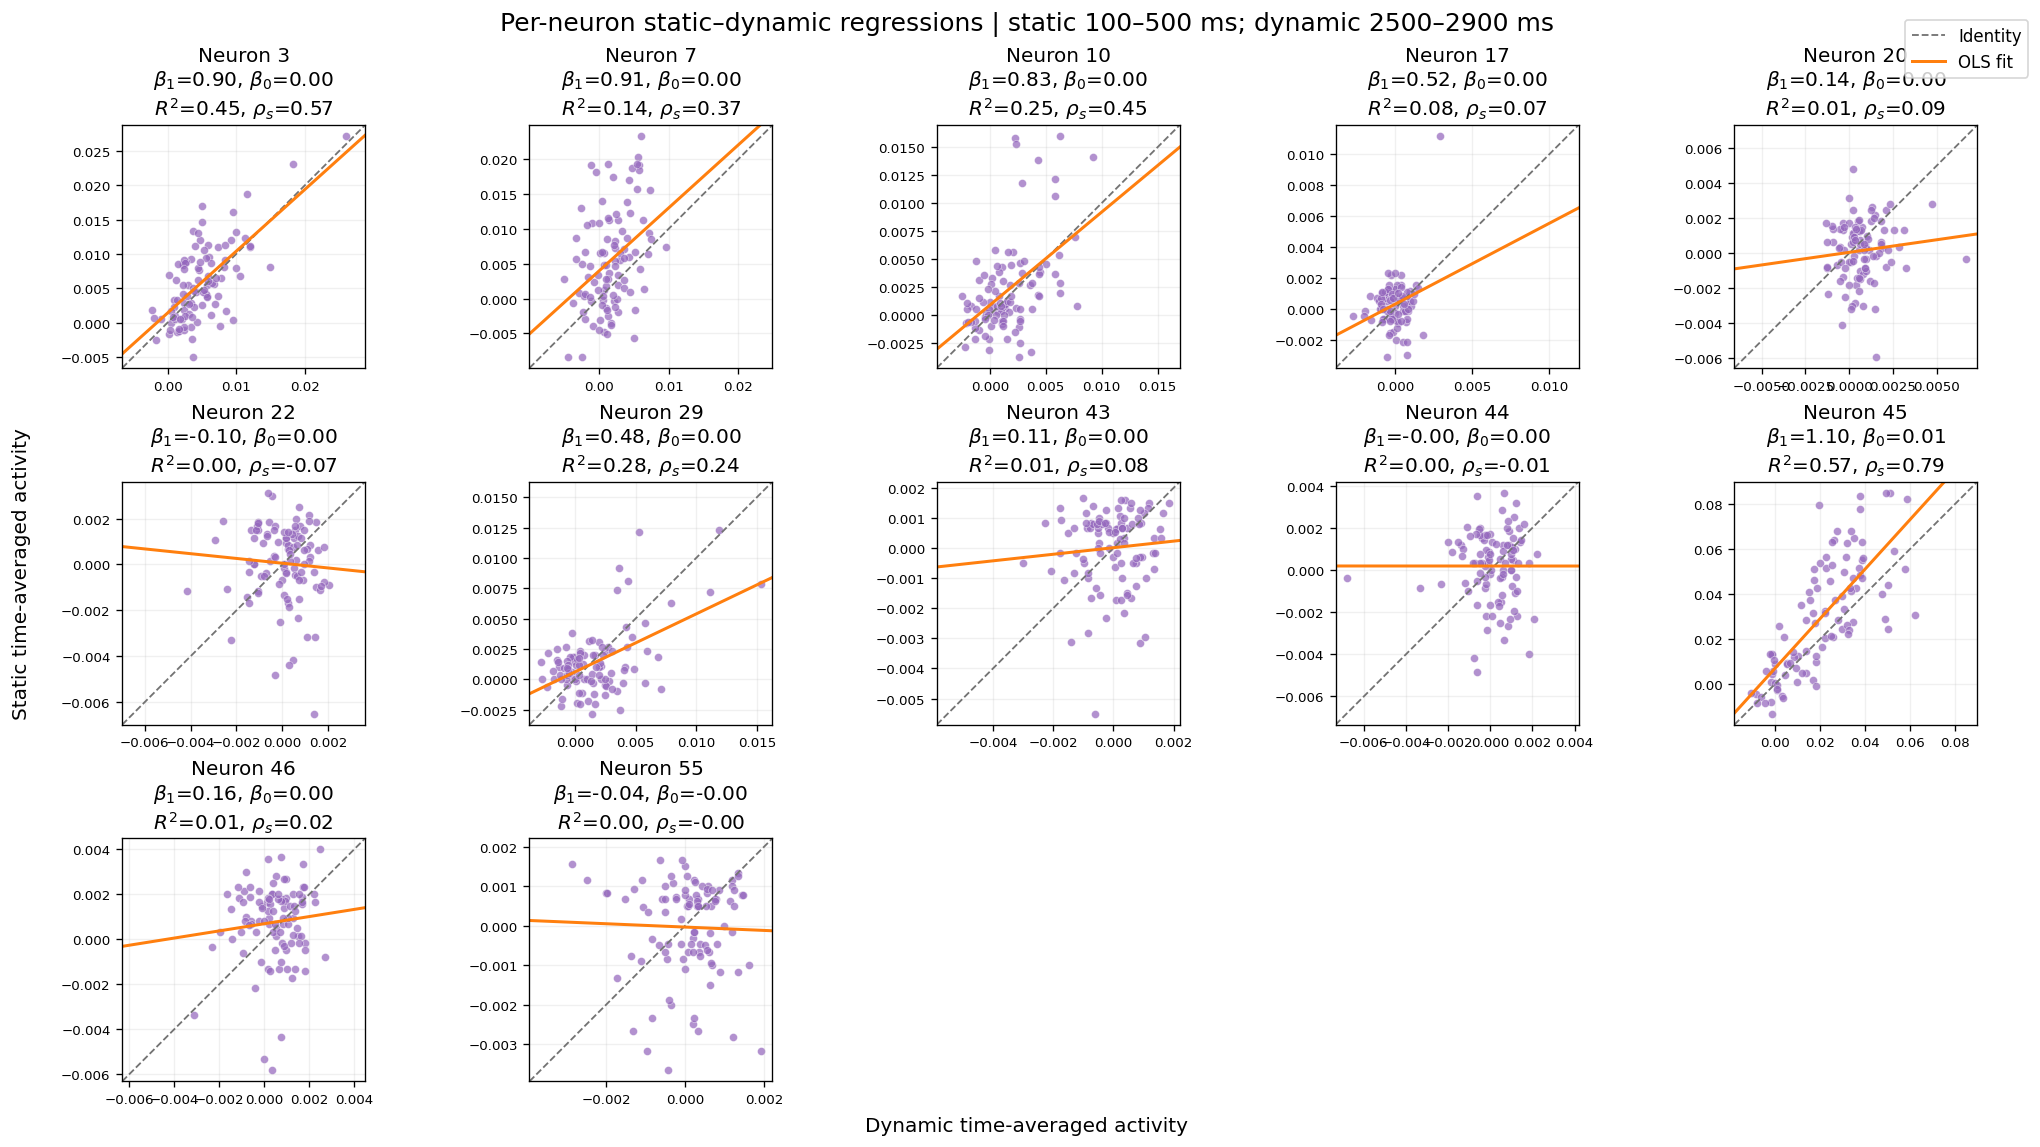

In [5]:
plot_column_count = min(cfg.neuron_plot_columns, neuron_count)
plot_row_count = int(np.ceil(neuron_count / plot_column_count))
figure, axes = plt.subplots(
    plot_row_count,
    plot_column_count,
    figsize=(3.4 * plot_column_count, 3.15 * plot_row_count),
    squeeze=False,
    constrained_layout=True,
)

for neuron_index, axis in enumerate(axes.flat[:neuron_count]):
    dynamic_activity = dynamic_channel_responses[neuron_index]
    static_activity = static_channel_responses[neuron_index]

    # Use common limits within the panel to preserve the identity comparison.
    activity_min = min(dynamic_activity.min(), static_activity.min())
    activity_max = max(dynamic_activity.max(), static_activity.max())
    activity_span = max(activity_max - activity_min, 1e-12)
    activity_padding = 0.05 * activity_span
    activity_limits = np.asarray((
        activity_min - activity_padding,
        activity_max + activity_padding,
    ))

    axis.scatter(
        dynamic_activity,
        static_activity,
        color="tab:purple",
        s=23,
        alpha=0.72,
        edgecolor="white",
        linewidth=0.3,
    )
    axis.plot(
        activity_limits, activity_limits, "--",
        color="0.45", linewidth=1.1, label="Identity",
    )

    if valid_regressions[neuron_index]:
        fitted_activity = (
            intercepts[neuron_index]
            + slopes[neuron_index] * activity_limits
        )
        axis.plot(
            activity_limits, fitted_activity,
            color="tab:orange", linewidth=1.8, label="OLS fit",
        )
        parameter_title = (
            rf"$\beta_1$={slopes[neuron_index]:.2f}, "
            rf"$\beta_0$={intercepts[neuron_index]:.2f}" "\n"
            f"$R^2$={r_squared[neuron_index]:.2f}, "
            rf"$\rho_s$={channel_rank_correlations[neuron_index]:.2f}"
        )
    else:
        parameter_title = "constant dynamic activity; fit undefined"
    # end if valid regression

    axis.set(
        xlim=activity_limits,
        ylim=activity_limits,
        aspect="equal",
        title=f"Neuron {channel_numbers[neuron_index]}\n{parameter_title}",
    )
    axis.tick_params(labelsize=8)
    axis.grid(alpha=0.18)
# end for neuron_index

# Hide unused panels when the neuron count does not fill the final row.
for axis in axes.flat[neuron_count:]:
    axis.set_visible(False)
# end for unused axis

figure.supxlabel("Dynamic time-averaged activity")
figure.supylabel("Static time-averaged activity")
figure.suptitle(
    f"Per-neuron static–dynamic regressions | "
    f"static {cfg.static_window_ms[0]:g}–{cfg.static_window_ms[1]:g} ms; "
    f"dynamic {analysis_dynamic_window_ms[0]:g}–"
    f"{analysis_dynamic_window_ms[1]:g} ms",
    fontsize=15,
)
legend_handles, legend_labels = axes.flat[0].get_legend_handles_labels()
figure.legend(
    legend_handles, legend_labels,
    loc="upper right", bbox_to_anchor=(0.995, 0.995),
)
plt.show()

## Distributions of slopes and intercepts

A slope of 1 and intercept of 0 correspond to equal static and dynamic response scales. These references do not imply that the fitted slope and intercept are statistically different from those values; the histograms are descriptive summaries across neurons.

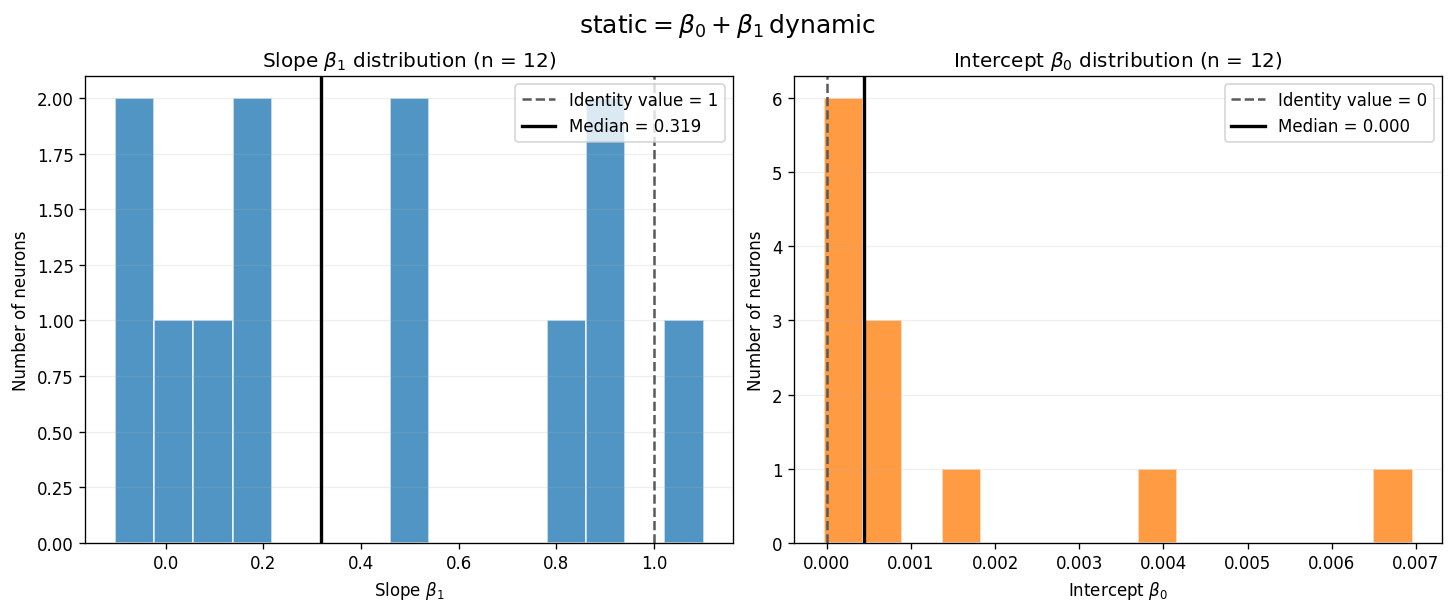

Slope summary: mean=0.417, median=0.319, min=-0.104, max=1.101
Intercept summary: mean=0.001, median=0.000, min=-0.000, max=0.007


In [6]:
finite_parameters = valid_regressions & np.isfinite(slopes) & np.isfinite(intercepts)
finite_slopes = slopes[finite_parameters]
finite_intercepts = intercepts[finite_parameters]

figure, axes = plt.subplots(
    1, 2, figsize=(12, 5), constrained_layout=True,
)
distribution_specs = (
    (axes[0], finite_slopes, 1, "tab:blue", r"Slope $\beta_1$"),
    (axes[1], finite_intercepts, 0, "tab:orange", r"Intercept $\beta_0$"),
)
for axis, values, reference, color, parameter_name in distribution_specs:
    axis.hist(
        values, bins=cfg.distribution_bin_count,
        color=color, alpha=0.78, edgecolor="white",
    )
    axis.axvline(
        reference, color="0.35", linestyle="--",
        linewidth=1.5, label=f"Identity value = {reference:g}",
    )
    axis.axvline(
        np.median(values), color="black", linewidth=2,
        label=f"Median = {np.median(values):.3f}",
    )
    axis.set(
        xlabel=parameter_name,
        ylabel="Number of neurons",
        title=f"{parameter_name} distribution (n = {len(values)})",
    )
    axis.legend()
    axis.grid(axis="y", alpha=0.2)
# end for distribution specification
figure.suptitle(
    r"$\mathrm{static} = \beta_0 + \beta_1 \, \mathrm{dynamic}$",
    fontsize=15,
)
plt.show()

print(
    "Slope summary: "
    f"mean={finite_slopes.mean():.3f}, "
    f"median={np.median(finite_slopes):.3f}, "
    f"min={finite_slopes.min():.3f}, max={finite_slopes.max():.3f}"
)
print(
    "Intercept summary: "
    f"mean={finite_intercepts.mean():.3f}, "
    f"median={np.median(finite_intercepts):.3f}, "
    f"min={finite_intercepts.min():.3f}, "
    f"max={finite_intercepts.max():.3f}"
)

## Why the population plot and neuron plots differ

The original population plot puts static activity on the x-axis and dynamic activity on the y-axis, whereas the requested neuron model above predicts static activity from dynamic activity. The cell below fits both OLS directions and an orthogonal line to the population averages. OLS slopes cannot be inverted by taking their reciprocal because each direction minimizes a different set of residuals.

The regression of population averages is also not the average of the neuron-wise regressions. Averaging responses before fitting includes cross-neuron stimulus covariance and suppresses neuron-specific variation.

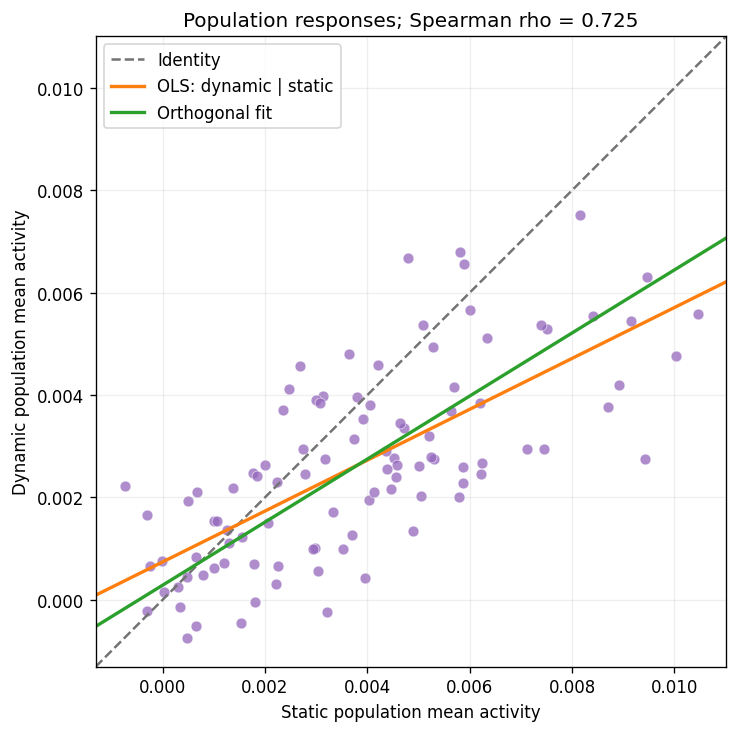

Population OLS static | dynamic slope: 0.996
Population OLS dynamic | static slope: 0.497
Reciprocal of static | dynamic slope: 1.004
Population orthogonal dynamic/static gain: 0.616
Mean neuron-wise static | dynamic slope: 0.417


In [7]:
# Average neurons first to reproduce the population-level observations.
static_population_responses = static_channel_responses.mean(axis=0)
dynamic_population_responses = dynamic_channel_responses.mean(axis=0)

population_static_on_dynamic = LinearRegression().fit(
    dynamic_population_responses[:, np.newaxis],
    static_population_responses,
)
population_dynamic_on_static = LinearRegression().fit(
    static_population_responses[:, np.newaxis],
    dynamic_population_responses,
)
population_orthogonal_intercept, population_orthogonal_gain = (
    rowwise_orthogonal_regression(
        static_population_responses[np.newaxis, :],
        dynamic_population_responses[np.newaxis, :],
    )
)
population_rank_correlation = rowwise_similarity(
    static_population_responses[np.newaxis, :],
    dynamic_population_responses[np.newaxis, :],
    metric="spearman",
)[0]

# Plot every population fit with the original static-x, dynamic-y orientation.
population_min = min(
    static_population_responses.min(),
    dynamic_population_responses.min(),
)
population_max = max(
    static_population_responses.max(),
    dynamic_population_responses.max(),
)
population_padding = 0.05 * max(population_max - population_min, 1e-12)
population_limits = np.asarray((
    population_min - population_padding,
    population_max + population_padding,
))

figure, axis = plt.subplots(figsize=(7, 6), constrained_layout=True)
axis.scatter(
    static_population_responses, dynamic_population_responses,
    color="tab:purple", s=42, alpha=0.75,
    edgecolor="white", linewidth=0.4,
)
axis.plot(
    population_limits, population_limits, "--",
    color="0.45", linewidth=1.5, label="Identity",
)
axis.plot(
    population_limits,
    population_dynamic_on_static.predict(population_limits[:, np.newaxis]),
    color="tab:orange", linewidth=2, label="OLS: dynamic | static",
)
axis.plot(
    population_limits,
    population_orthogonal_intercept[0]
    + population_orthogonal_gain[0] * population_limits,
    color="tab:green", linewidth=2, label="Orthogonal fit",
)
axis.set(
    xlim=population_limits, ylim=population_limits, aspect="equal",
    xlabel="Static population mean activity",
    ylabel="Dynamic population mean activity",
    title=f"Population responses; Spearman rho = {population_rank_correlation:.3f}",
)
axis.legend()
axis.grid(alpha=0.2)
plt.show()

population_beta_1 = population_static_on_dynamic.coef_[0]
population_gamma_1 = population_dynamic_on_static.coef_[0]
print(f"Population OLS static | dynamic slope: {population_beta_1:.3f}")
print(f"Population OLS dynamic | static slope: {population_gamma_1:.3f}")
print(f"Reciprocal of static | dynamic slope: {1 / population_beta_1:.3f}")
print(f"Population orthogonal dynamic/static gain: {population_orthogonal_gain[0]:.3f}")
print(f"Mean neuron-wise static | dynamic slope: {finite_slopes.mean():.3f}")

## Separate mean response level from stimulus modulation

A fitted intercept mixes the two conditions' mean response levels with their slope. The following diagnostics therefore compare each neuron's mean response across stimuli and its stimulus-driven modulation amplitude, measured as the standard deviation across matched stimuli.

The mean response difference is not a physiological prestimulus baseline measurement. A true baseline comparison would require a specified prestimulus window in both recordings.

For the original OLS model, the slope obeys `beta_1 = Pearson correlation / (dynamic SD / static SD)`. Therefore, imperfect tuning agreement can push `beta_1` below 1 even when the dynamic modulation SD is smaller than the static modulation SD.

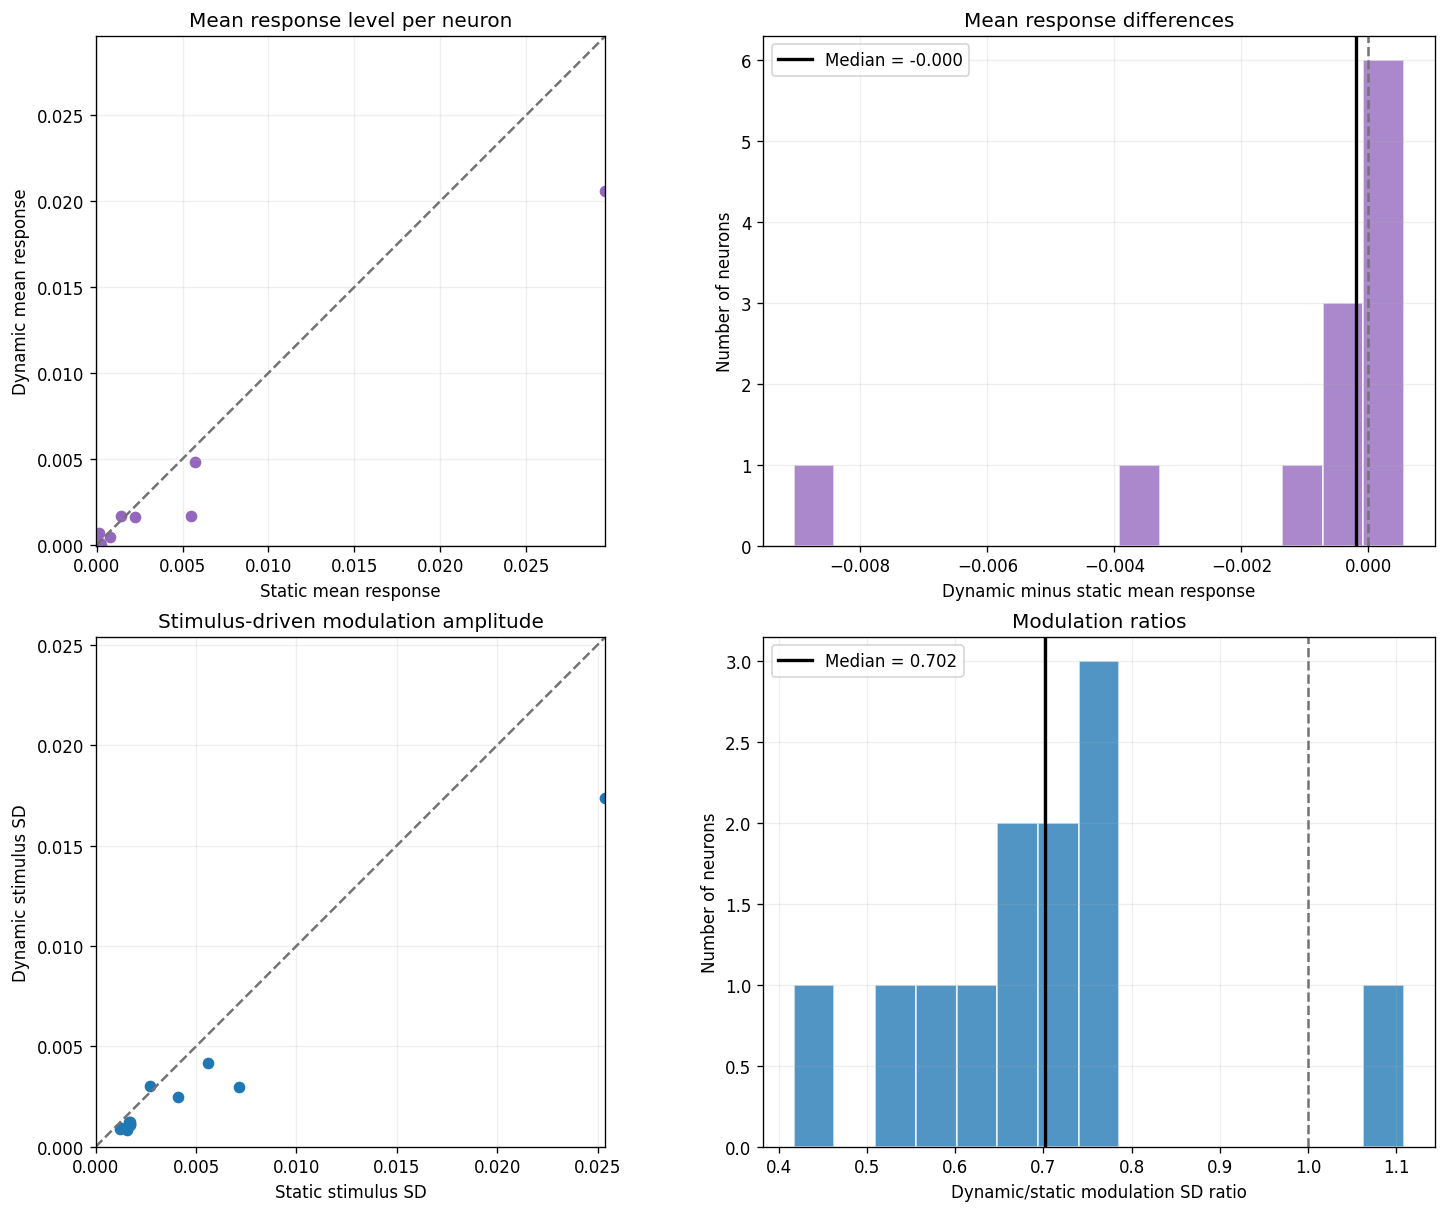

Median dynamic-static mean response: -0.000
Neurons with higher dynamic mean response: 3 / 12
Median neuron-wise Pearson correlation: 0.190
Median dynamic/static modulation SD ratio: 0.702
Neurons with larger dynamic modulation: 1 / 12


In [8]:
static_mean_responses = static_channel_responses.mean(axis=1)
dynamic_mean_responses = dynamic_channel_responses.mean(axis=1)
mean_response_differences = dynamic_mean_responses - static_mean_responses

# Standard deviation across stimuli quantifies tuning modulation amplitude.
static_modulation_amplitudes = static_channel_responses.std(axis=1, ddof=1)
dynamic_modulation_amplitudes = dynamic_channel_responses.std(axis=1, ddof=1)
valid_modulation_ratios = static_modulation_amplitudes > 0
modulation_amplitude_ratios = np.full(neuron_count, np.nan)
modulation_amplitude_ratios[valid_modulation_ratios] = (
    dynamic_modulation_amplitudes[valid_modulation_ratios]
    / static_modulation_amplitudes[valid_modulation_ratios]
)
ols_slopes_from_components = (
    channel_linear_correlations / modulation_amplitude_ratios
)
if not np.allclose(
        slopes[valid_regressions],
        ols_slopes_from_components[valid_regressions],
        rtol=1e-5, atol=1e-7,
        ):
    raise ValueError("OLS slopes do not match correlation/SD decomposition.")
# end if OLS decomposition mismatch

figure, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

# Mean response comparison.
mean_min = min(static_mean_responses.min(), dynamic_mean_responses.min())
mean_max = max(static_mean_responses.max(), dynamic_mean_responses.max())
mean_limits = np.asarray((mean_min, mean_max))
axes[0, 0].scatter(static_mean_responses, dynamic_mean_responses, color="tab:purple")
axes[0, 0].plot(mean_limits, mean_limits, "--", color="0.45")
axes[0, 0].set(
    xlim=mean_limits, ylim=mean_limits, aspect="equal",
    xlabel="Static mean response", ylabel="Dynamic mean response",
    title="Mean response level per neuron",
)

axes[0, 1].hist(
    mean_response_differences, bins=cfg.distribution_bin_count,
    color="tab:purple", alpha=0.78, edgecolor="white",
)
axes[0, 1].axvline(0, color="0.45", linestyle="--")
axes[0, 1].axvline(
    np.median(mean_response_differences), color="black", linewidth=2,
    label=f"Median = {np.median(mean_response_differences):.3f}",
)
axes[0, 1].set(
    xlabel="Dynamic minus static mean response",
    ylabel="Number of neurons", title="Mean response differences",
)
axes[0, 1].legend()

# Stimulus-modulation comparison.
modulation_max = max(
    static_modulation_amplitudes.max(),
    dynamic_modulation_amplitudes.max(),
)
modulation_limits = np.asarray((0, modulation_max))
axes[1, 0].scatter(
    static_modulation_amplitudes, dynamic_modulation_amplitudes,
    color="tab:blue",
)
axes[1, 0].plot(modulation_limits, modulation_limits, "--", color="0.45")
axes[1, 0].set(
    xlim=modulation_limits, ylim=modulation_limits, aspect="equal",
    xlabel="Static stimulus SD", ylabel="Dynamic stimulus SD",
    title="Stimulus-driven modulation amplitude",
)

finite_modulation_ratios = modulation_amplitude_ratios[np.isfinite(
    modulation_amplitude_ratios
)]
axes[1, 1].hist(
    finite_modulation_ratios, bins=cfg.distribution_bin_count,
    color="tab:blue", alpha=0.78, edgecolor="white",
)
axes[1, 1].axvline(1, color="0.45", linestyle="--")
axes[1, 1].axvline(
    np.median(finite_modulation_ratios), color="black", linewidth=2,
    label=f"Median = {np.median(finite_modulation_ratios):.3f}",
)
axes[1, 1].set(
    xlabel="Dynamic/static modulation SD ratio",
    ylabel="Number of neurons", title="Modulation ratios",
)
axes[1, 1].legend()
for axis in axes.flat:
    axis.grid(alpha=0.2)
# end for axis
plt.show()

print(
    f"Median dynamic-static mean response: "
    f"{np.median(mean_response_differences):.3f}"
)
print(
    f"Neurons with higher dynamic mean response: "
    f"{np.sum(mean_response_differences > 0)} / {neuron_count}"
)
print(
    f"Median neuron-wise Pearson correlation: "
    f"{np.median(channel_linear_correlations):.3f}"
)
print(
    f"Median dynamic/static modulation SD ratio: "
    f"{np.median(finite_modulation_ratios):.3f}"
)
print(
    f"Neurons with larger dynamic modulation: "
    f"{np.sum(finite_modulation_ratios > 1)} / "
    f"{len(finite_modulation_ratios)}"
)

## Symmetric dynamic/static gain estimate

Ordinary least squares assumes that its x-axis is measured without error, which is not appropriate when both neural-response estimates are noisy. Here, orthogonal regression fits the principal axis of each neuron's mean-centered static/dynamic tuning points. Its slope is reported in the intuitive direction `dynamic = offset + gain * static`. A gain above 1 means a larger dynamic tuning modulation, while a gain below 1 means a larger static modulation.

The paired bootstrap resamples matched stimuli and supplies descriptive confidence intervals. Orthogonal regression assumes comparable error scales in the two conditions; repeated-presentation noise estimates would be needed for a fully specified Deming regression.

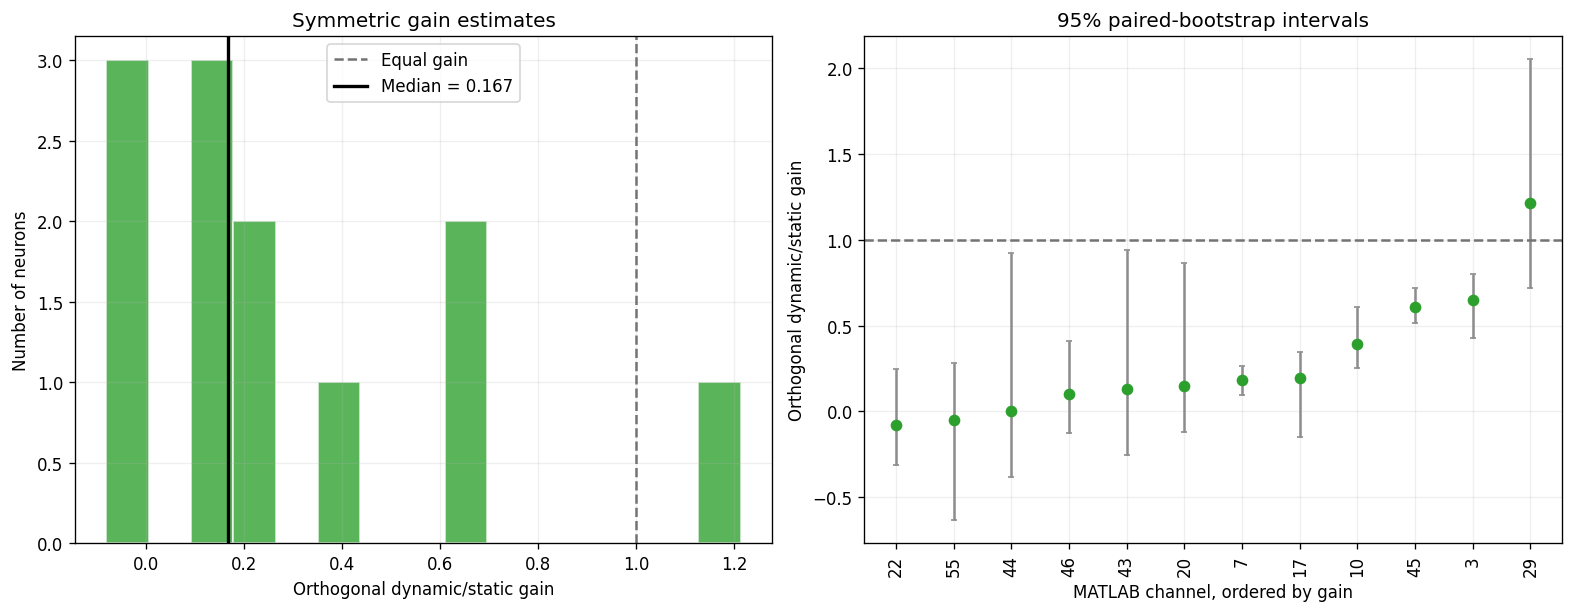

Median orthogonal dynamic/static gain: 0.167
Bootstrap intervals entirely above 1: 0 / 12
Bootstrap intervals containing 1: 1 / 12
Bootstrap intervals entirely below 1: 11 / 12


In [9]:
orthogonal_intercepts, orthogonal_dynamic_gains = (
    rowwise_orthogonal_regression(
        static_channel_responses, dynamic_channel_responses,
    )
)
orthogonal_gain_confidence_intervals = (
    bootstrap_rowwise_orthogonal_slopes(
        static_channel_responses,
        dynamic_channel_responses,
        bootstrap_repeats=cfg.bootstrap_repeats,
        confidence_level=cfg.bootstrap_confidence_level,
        random_seed=cfg.random_seed,
    )
)
finite_orthogonal_gains = np.isfinite(orthogonal_dynamic_gains)
gains_above_one = (
    finite_orthogonal_gains
    & (orthogonal_gain_confidence_intervals[:, 0] > 1)
)
gains_below_one = (
    finite_orthogonal_gains
    & (orthogonal_gain_confidence_intervals[:, 1] < 1)
)
gains_including_one = (
    finite_orthogonal_gains & ~gains_above_one & ~gains_below_one
)

figure, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
finite_gain_values = orthogonal_dynamic_gains[finite_orthogonal_gains]
axes[0].hist(
    finite_gain_values, bins=cfg.distribution_bin_count,
    color="tab:green", alpha=0.78, edgecolor="white",
)
axes[0].axvline(1, color="0.45", linestyle="--", label="Equal gain")
axes[0].axvline(
    np.median(finite_gain_values), color="black", linewidth=2,
    label=f"Median = {np.median(finite_gain_values):.3f}",
)
axes[0].set(
    xlabel="Orthogonal dynamic/static gain",
    ylabel="Number of neurons", title="Symmetric gain estimates",
)
axes[0].legend()

# Sort neurons by gain so the confidence intervals remain readable.
gain_order = np.argsort(orthogonal_dynamic_gains[finite_orthogonal_gains])
ordered_gains = finite_gain_values[gain_order]
ordered_intervals = orthogonal_gain_confidence_intervals[
    finite_orthogonal_gains
][gain_order]
ordered_channels = channel_numbers[finite_orthogonal_gains][gain_order]
gain_errors = np.vstack((
    ordered_gains - ordered_intervals[:, 0],
    ordered_intervals[:, 1] - ordered_gains,
))
axes[1].errorbar(
    np.arange(len(ordered_gains)), ordered_gains, yerr=gain_errors,
    fmt="o", color="tab:green", ecolor="0.55", capsize=2,
)
axes[1].axhline(1, color="0.45", linestyle="--")
axes[1].set(
    xticks=np.arange(len(ordered_channels)),
    xticklabels=ordered_channels,
    xlabel="MATLAB channel, ordered by gain",
    ylabel="Orthogonal dynamic/static gain",
    title=f"{100 * cfg.bootstrap_confidence_level:.0f}% paired-bootstrap intervals",
)
axes[1].tick_params(axis="x", rotation=90)
for axis in axes:
    axis.grid(alpha=0.2)
# end for axis
plt.show()

print(f"Median orthogonal dynamic/static gain: {np.median(finite_gain_values):.3f}")
print(
    f"Bootstrap intervals entirely above 1: "
    f"{gains_above_one.sum()} / {finite_orthogonal_gains.sum()}"
)
print(
    f"Bootstrap intervals containing 1: "
    f"{gains_including_one.sum()} / {finite_orthogonal_gains.sum()}"
)
print(
    f"Bootstrap intervals entirely below 1: "
    f"{gains_below_one.sum()} / {finite_orthogonal_gains.sum()}"
)

## Interpretation guide

- A neuron-wise `static | dynamic` OLS slope below 1 is not a direct dynamic-gain estimate. It combines tuning agreement and the inverse modulation ratio: `beta_1 = Pearson correlation / (dynamic SD / static SD)`.
- A positive dynamic-minus-static mean response indicates a higher overall response level in the selected dynamic window. It should not be called a baseline shift without prestimulus measurements.
- A dynamic/static modulation SD ratio above 1 directly indicates that responses vary more strongly across stimuli in the dynamic condition. It does not require the two tuning curves to be perfectly aligned.
- An orthogonal dynamic/static gain above 1 indicates expansion along the shared static-dynamic tuning axis. A bootstrap interval entirely above 1 is stronger descriptive evidence than the point estimate alone.
- Population Spearman correlation measures preservation of stimulus ordering. It is invariant to offsets and positive rescaling, so it does not measure response equality or gain.

## Analysis outputs

The dictionary below retains the averaged response matrices and all per-neuron fit parameters for downstream analyses. Array rows follow `channel_numbers`; response columns follow `shared_stimuli`.

In [10]:
per_neuron_regression_results = {
    "static_response": cfg.static_response,
    "selected_frame_time_ms": selected_frame_time_ms,
    "static_window_ms": np.asarray(cfg.static_window_ms),
    "dynamic_window_ms": np.asarray(analysis_dynamic_window_ms),
    "shared_stimuli": np.asarray(shared_stimuli),
    "channel_numbers": channel_numbers,
    "static_channel_responses": static_channel_responses,
    "dynamic_channel_responses": dynamic_channel_responses,
    "intercepts": intercepts,
    "slopes": slopes,
    "r_squared": r_squared,
    "spearman_correlations": channel_rank_correlations,
    "pearson_correlations": channel_linear_correlations,
    "valid_regressions": valid_regressions,
    "static_population_responses": static_population_responses,
    "dynamic_population_responses": dynamic_population_responses,
    "population_static_on_dynamic_slope": population_beta_1,
    "population_dynamic_on_static_slope": population_gamma_1,
    "population_orthogonal_dynamic_gain": population_orthogonal_gain[0],
    "static_mean_responses": static_mean_responses,
    "dynamic_mean_responses": dynamic_mean_responses,
    "mean_response_differences": mean_response_differences,
    "static_modulation_amplitudes": static_modulation_amplitudes,
    "dynamic_modulation_amplitudes": dynamic_modulation_amplitudes,
    "modulation_amplitude_ratios": modulation_amplitude_ratios,
    "orthogonal_intercepts": orthogonal_intercepts,
    "orthogonal_dynamic_gains": orthogonal_dynamic_gains,
    "orthogonal_gain_confidence_intervals": (
        orthogonal_gain_confidence_intervals
    ),
    "orthogonal_gains_above_one": gains_above_one,
    "orthogonal_gains_below_one": gains_below_one,
}

print("Available per_neuron_regression_results fields:")
print("\n".join(
    f"- {field_name}"
    for field_name in per_neuron_regression_results
))

Available per_neuron_regression_results fields:
- static_response
- selected_frame_time_ms
- static_window_ms
- dynamic_window_ms
- shared_stimuli
- channel_numbers
- static_channel_responses
- dynamic_channel_responses
- intercepts
- slopes
- r_squared
- spearman_correlations
- pearson_correlations
- valid_regressions
- static_population_responses
- dynamic_population_responses
- population_static_on_dynamic_slope
- population_dynamic_on_static_slope
- population_orthogonal_dynamic_gain
- static_mean_responses
- dynamic_mean_responses
- mean_response_differences
- static_modulation_amplitudes
- dynamic_modulation_amplitudes
- modulation_amplitude_ratios
- orthogonal_intercepts
- orthogonal_dynamic_gains
- orthogonal_gain_confidence_intervals
- orthogonal_gains_above_one
- orthogonal_gains_below_one
